## Industrial Energy Forecast Dataset
IIoT-based resource use & prediction

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sqlalchemy import create_engine
from stack_data.utils import collapse_repeated
from unicodedata import category

df = pd.read_csv(r"C:\Users\User\Downloads\energy\data\Energy_dataset.csv")
df


,timestamp,machine_id,operation_id,energy_kWh,voltage_V,current_A,power_factor,reactive_power_kVAR,frequency_Hz,machine_utilization_%,production_output_units,operator_count,material_usage_kg,ambient_temp_C,humidity_%,shift_type,production_mode,forecast_energy_kWh,energy_state,allocation_recommendation
0,2025-07-01 00:00:00,MCH_1,OP_05,9.75,395.41,24.66,0.974,3.42,50.04,60.95,119,4,57.53,22.14,50.93,Night,Idle,11.18,Normal,Maintain
1,2025-07-01 00:05:00,MCH_1,OP_01,10.64,400.63,26.55,0.859,2.78,49.91,66.77,88,3,57.32,28.02,61.63,Night,Setup,11.25,High,Reduce Load
2,2025-07-01 00:10:00,MCH_1,OP_08,10.92,395.18,27.64,0.898,3.34,50.04,60.86,84,2,45.52,29.38,59.82,Day,Setup,10.69,High,Reduce Load
3,2025-07-01 00:15:00,MCH_1,OP_05,10.87,405.20,26.83,0.935,3.90,49.91,69.51,96,3,58.55,24.30,46.94,Night,Idle,12.94,High,Reduce Load
4,2025-07-01 00:20:00,MCH_1,OP_05,10.07,400.87,25.13,0.966,4.34,49.90,82.90,104,3,42.41,25.49,56.39,Day,Production,9.69,High,Reduce Load
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2025-07-01 19:35:00,MCH_5,OP_03,10.64,399.48,26.64,0.910,2.53,49.92,70.07,118,4,56.74,21.43,48.44,Night,Setup,10.15,High,Reduce Load
1196,2025-07-01 19:40:00,MCH_5,OP_03,10.51,393.40,26.71,0.867,3.32,49.93,64.36,109,4,33.78,22.24,44.61,Night,Idle,10.43,High,Reduce Load
1197,2025-07-01 19:45:00,MCH_5,OP_05,11.69,408.01,28.66,0.978,2.68,49.97,90.00,100,3,50.11,30.77,62.66,Night,Production,12.75,High,Reduce Load
1198,2025-07-01 19:50:00,MCH_5,OP_03,11.40,401.79,28.37,0.967,3.19,50.04,74.99,111,2,38.79,23.97,59.69,Night,Setup,10.94,High,Reduce Load


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  1200 non-null   str    
 1   machine_id                 1200 non-null   str    
 2   operation_id               1200 non-null   str    
 3   energy_kWh                 1200 non-null   float64
 4   voltage_V                  1200 non-null   float64
 5   current_A                  1200 non-null   float64
 6   power_factor               1200 non-null   float64
 7   reactive_power_kVAR        1200 non-null   float64
 8   frequency_Hz               1200 non-null   float64
 9   machine_utilization_%      1200 non-null   float64
 10  production_output_units    1200 non-null   int64  
 11  operator_count             1200 non-null   int64  
 12  material_usage_kg          1200 non-null   float64
 13  ambient_temp_C             1200 non-null   float64
 14  hum

In [9]:
df.describe()

,energy_kWh,voltage_V,current_A,power_factor,reactive_power_kVAR,frequency_Hz,machine_utilization_%,production_output_units,operator_count,material_usage_kg,ambient_temp_C,humidity_%,forecast_energy_kWh
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,11.84610,400.167575,29.604325,0.914106,3.515817,49.990933,78.373625,100.133333,3.014167,44.933992,27.406008,55.001733,11.815992
std,2.81761,4.884478,7.039204,0.037601,0.863338,0.102074,10.260336,9.835285,0.811078,8.499127,4.365032,8.692682,2.938620
min,6.48000,379.670000,16.040000,0.850000,2.000000,49.660000,60.010000,66.000000,2.000000,30.000000,20.020000,40.060000,5.290000
25%,9.67000,397.027500,24.147500,0.882000,2.770000,49.920000,69.417500,94.000000,2.000000,37.440000,23.615000,47.240000,9.670000
50%,11.53500,400.150000,28.875000,0.914000,3.515000,49.990000,78.875000,100.000000,3.000000,45.365000,27.405000,54.905000,11.455000
75%,13.56250,403.472500,34.050000,0.947000,4.272500,50.060000,87.165000,107.000000,4.000000,51.752500,31.155000,62.372500,13.702500
max,19.79000,414.650000,50.300000,0.980000,5.000000,50.380000,95.000000,133.000000,4.000000,60.000000,35.000000,69.980000,20.340000


In [10]:
df.isna().sum() #dataset in clean

timestamp                    0
machine_id                   0
operation_id                 0
energy_kWh                   0
voltage_V                    0
current_A                    0
power_factor                 0
reactive_power_kVAR          0
frequency_Hz                 0
machine_utilization_%        0
production_output_units      0
operator_count               0
material_usage_kg            0
ambient_temp_C               0
humidity_%                   0
shift_type                   0
production_mode              0
forecast_energy_kWh          0
energy_state                 0
allocation_recommendation    0
dtype: int64

In [12]:
df.duplicated().sum() #no duplicated values

np.int64(0)

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df

,timestamp,machine_id,operation_id,energy_kWh,voltage_V,current_A,power_factor,reactive_power_kVAR,frequency_Hz,machine_utilization_%,...,material_usage_kg,ambient_temp_C,humidity_%,shift_type,production_mode,forecast_energy_kWh,energy_state,allocation_recommendation,hour,month
0,2025-07-01 00:00:00,MCH_1,OP_05,9.75,395.41,24.66,0.974,3.42,50.04,60.95,...,57.53,22.14,50.93,Night,Idle,11.18,Normal,Maintain,0,7
1,2025-07-01 00:05:00,MCH_1,OP_01,10.64,400.63,26.55,0.859,2.78,49.91,66.77,...,57.32,28.02,61.63,Night,Setup,11.25,High,Reduce Load,0,7
2,2025-07-01 00:10:00,MCH_1,OP_08,10.92,395.18,27.64,0.898,3.34,50.04,60.86,...,45.52,29.38,59.82,Day,Setup,10.69,High,Reduce Load,0,7
3,2025-07-01 00:15:00,MCH_1,OP_05,10.87,405.20,26.83,0.935,3.90,49.91,69.51,...,58.55,24.30,46.94,Night,Idle,12.94,High,Reduce Load,0,7
4,2025-07-01 00:20:00,MCH_1,OP_05,10.07,400.87,25.13,0.966,4.34,49.90,82.90,...,42.41,25.49,56.39,Day,Production,9.69,High,Reduce Load,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2025-07-01 19:35:00,MCH_5,OP_03,10.64,399.48,26.64,0.910,2.53,49.92,70.07,...,56.74,21.43,48.44,Night,Setup,10.15,High,Reduce Load,19,7
1196,2025-07-01 19:40:00,MCH_5,OP_03,10.51,393.40,26.71,0.867,3.32,49.93,64.36,...,33.78,22.24,44.61,Night,Idle,10.43,High,Reduce Load,19,7
1197,2025-07-01 19:45:00,MCH_5,OP_05,11.69,408.01,28.66,0.978,2.68,49.97,90.00,...,50.11,30.77,62.66,Night,Production,12.75,High,Reduce Load,19,7
1198,2025-07-01 19:50:00,MCH_5,OP_03,11.40,401.79,28.37,0.967,3.19,50.04,74.99,...,38.79,23.97,59.69,Night,Setup,10.94,High,Reduce Load,19,7


### Energy usage per machine

In [58]:
df.groupby("machine_id")["energy_kWh"].agg(["sum"]).sort_values("sum", ascending=False)

,sum
machine_id,
MCH_2,3553.83
MCH_4,3323.00
MCH_5,2689.23
MCH_1,2490.24
MCH_3,2159.02


In [53]:
df.groupby("machine_id")["energy_kWh"].agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False)

,mean,std,min,max
machine_id,,,,
MCH_2,14.807625,2.259885,10.29,19.79
MCH_4,13.845833,2.063467,9.85,18.02
MCH_5,11.205125,1.700682,7.97,14.80
MCH_1,10.376000,1.503131,7.43,14.27
MCH_3,8.995917,1.321916,6.48,11.70


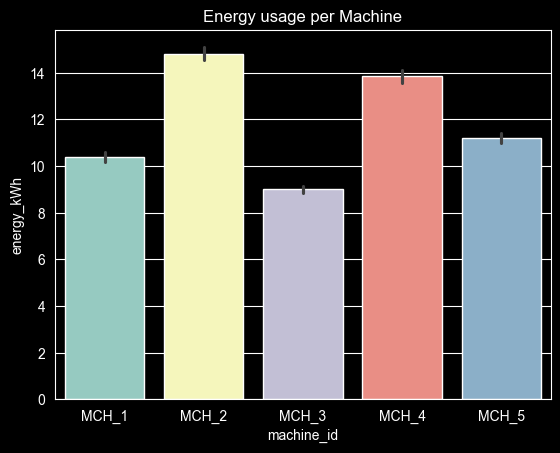

In [23]:
sns.barplot(x="machine_id", y="energy_kWh", data=df, hue="machine_id")
plt.title(f"Energy usage per Machine ")
plt.show()

### Energy peak usage and average

In [19]:
df["energy_kWh"].describe()

count    1200.00000
mean       11.84610
std         2.81761
min         6.48000
25%         9.67000
50%        11.53500
75%        13.56250
max        19.79000
Name: energy_kWh, dtype: float64

### Energy usage

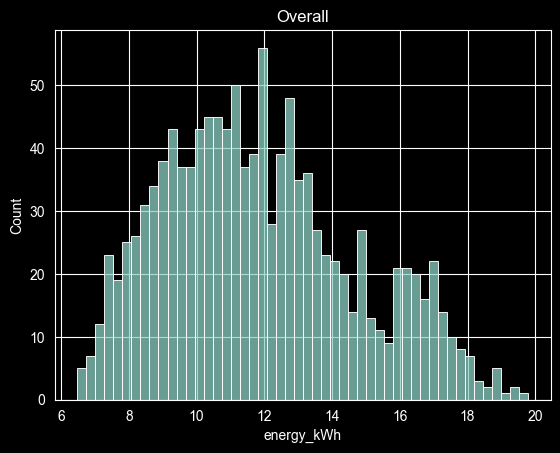

In [60]:
sns.histplot(df["energy_kWh"], bins=50)
plt.title(f"Overall")
plt.show()

### Analyze Energy Over Time

In [62]:
df["hour"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19], dtype=int32)

In [63]:
df.groupby("hour")["energy_kWh"].agg(["sum"])

,sum
hour,
0,730.86
1,772.35
2,810.60
3,835.44
4,853.45
5,851.31
6,833.85
7,809.70
8,774.07


### Data Preprocessing


In [78]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
pre = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", OneHotEncoder(), lambda x: x[df]),
        ("StandardScaler", StandardScaler(), lambda x: x[df])
    ]
)

### Pipeline

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=0, max_depth=10)

In [73]:
pipeline = Pipeline(
    [
        ("preprocessor", pre),
        ("classifier", rf),
    ]
)

In [75]:
df.dtypes

timestamp                    datetime64[us]
machine_id                              str
operation_id                            str
energy_kWh                          float64
voltage_V                           float64
current_A                           float64
power_factor                        float64
reactive_power_kVAR                 float64
frequency_Hz                        float64
machine_utilization_%               float64
production_output_units               int64
operator_count                        int64
material_usage_kg                   float64
ambient_temp_C                      float64
humidity_%                          float64
shift_type                              str
production_mode                         str
forecast_energy_kWh                 float64
energy_state                            str
allocation_recommendation               str
hour                                  int32
month                                 int32
dtype: object

### Train Test

In [79]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "str":
        df[col] = le.fit_transform(df[col])



In [ ]:
y = df["allocation_recommendation"]
x = df.drop(["allocation_recommendation", "timestamp", ], axis=1)